Для 1 лаб работы по CV необходимо реализовать базовый минимум операций над изображениями
Входное изображение в формате (RGB, не чёрно-белое)
1. Фильтры

1.1 Медианный фильтр

1.2 Фильтр гаусса

2. Морфологические операции

2.1 Эрозия

2.2 Дилатация

3. Прочие операции

3.1 пороговая бинаризация (для rgb и grayscale изображения)

3.2 выравнивание гистограммы

3.3 поворот изображений на угол кратный 90 градусов


In [41]:
#%matplotlib inline

In [56]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
from tqdm import tqdm #

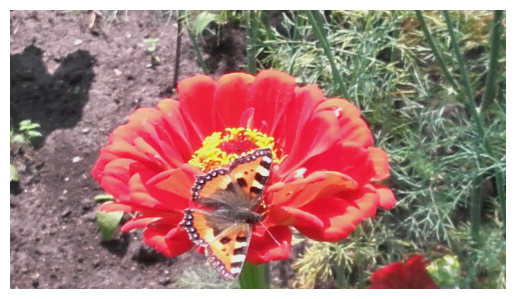

In [57]:
image1 = mpimg.imread('../Sourse_Images/butterfly_on_a_flower.jpg')
plt.imshow(image1)
plt.axis('off')  # скрыть оси
plt.show()

In [58]:
print(f"Размер: {image1.shape}")
print(f"Тип данных: {image1.dtype}")

Размер: (1836, 3264, 3)
Тип данных: uint8


# 1. Фильтры

## 1.1 Медианный фильтр

In [59]:
def Median_filter(image: np.ndarray, filtersize: int = 3, expand: int = 0, grout: bool = False, verbose: bool = False) -> np.ndarray:
    """
    image - исходное изображение массив np.ndarray (Н, W, C) H-высота, W - ширина, C - число каналов
    filtersize - размер стороны ядра свёртки, должно быть нечётное число
    expand - расширение изображение
    expand = 0 - не расширяет 
    expand = 1 - зеркало с дублированием края
    expand = 2 - зеркало без дублирования края
    verbose - вывод массивов, по которым происходит выбор
    grout - выбирать большее значение за медиану, только при expand = 0
    
    """
    H = image.shape[0]
    W = image.shape[1]
    C = image.shape[2]
    edge = 1
    if (filtersize % 2 and filtersize > 0):
        edge = (filtersize - 1) // 2
    else:
        ####Error
        raise ValueError("Размер ядра должен быть нечетным числом")
        # res_image = np.zeros((H, W, C))

    # kernel = np.zeros((filtersize, filtersize))
    buf_image = np.zeros((H + 2 * edge, W + 2 * edge, C), dtype=image.dtype)  # np.uint8

    buf_image[edge: H + edge, edge: W + edge, :] = image #image.copy()

    if expand == 0:
        res_image = np.zeros((H, W, C), dtype=image.dtype)  # dtype=image.dtype)
        for k in tqdm(range(C)):
            for i in range(H):
                for j in range(W):
                    value_array = np.zeros(1, dtype=image.dtype)#dtype=np.uint8
                    flag_first = True
                    for jl in range(2 * edge + 1):
                        for il in range(2 * edge + 1):
                            H_i = i - edge + il
                            W_j = j - edge + jl

                            if(H_i >=0 and W_j >=0 and H_i < H and W_j < W):
                                element = image[H_i, W_j, k]
                                if (flag_first == True):
                                    value_array[0] = element
                                    flag_first = False
                                else:
                                    arr_len = len(value_array)
                                    for pos in range(arr_len):
                                        if (value_array[pos] >= element):
                                            value_array1 = np.insert(value_array, pos, element)
                                            value_array = value_array1
                                            break
                                        elif (pos == arr_len - 1):
                                            value_array1 = np.append(value_array, element)
                                            value_array = value_array1
                            else:
                                continue
                    if (verbose):
                        for q in range(len(value_array)):
                            print(f"{value_array[q]} ", end='')
                        print()
                    arr_len = len(value_array)
                    center = arr_len // 2
                    if (grout):
                        if (center > 1 and arr_len % 2 == 0):
                            center = center + 1
                    value = value_array[center]
                    res_image[i][j][k] = value

    else:
        if expand == 1:
            bias = 0
        elif expand == 2:
            bias = 1      
        else:
            raise ValueError("Некорректное значения для расширения изображения")
        for ed in range(1, edge+1):  
            for k in range(C):
                buf_image[edge-ed:edge-ed+1,edge:W+edge] = image[ed-1+bias:ed+bias, :]
                buf_image[edge+H+ed-1:edge+H+ed,edge:W+edge] = image[H-ed-bias:H-ed+1-bias, :]
        for ed in range(1, edge+1):  
            for k in range(C):
                buf_image[:,edge-ed:edge-ed+1] = buf_image[:, edge+ed-1+bias:edge+ed+bias]
                buf_image[:,W+edge+ed-1:W+edge+ed] = buf_image[:, W+edge-ed-bias:W+edge-ed+1-bias]                
       
        res_image = np.zeros((H, W, C))  # dtype=image.dtype)
        for k in tqdm(range(C)):
            for i in range(H):
                for j in range(W):
                    value_array = np.zeros(1, dtype=image.dtype)#dtype=np.uint8
                    flag_first = True
                    for jl in range(2 * edge + 1):
                        for il in range(2 * edge + 1):
                            H_i = i - edge + il
                            W_j = j - edge + jl

                            if(H_i >=0 and W_j >=0 and H_i < H and W_j < W):
                                element = image[H_i, W_j, k]
                                if (flag_first == True):
                                    value_array[0] = element
                                    flag_first = False
                                else:
                                    arr_len = len(value_array)
                                    for pos in range(arr_len):
                                        if (value_array[pos] >= element):
                                            value_array1 = np.insert(value_array, pos, element)
                                            value_array = value_array1
                                            break
                                        elif (pos == arr_len - 1):
                                            value_array1 = np.append(value_array, element)
                                            value_array = value_array1
                            else:
                                continue
                    if(verbose): 
                        for q in range(len(value_array)):
                            print(f"{value_array[q]} ", end='')
                        print()
                    arr_len = len(value_array)
                    center =arr_len // 2
                    value = value_array[center]
                    res_image[i][j][k] = value
    return res_image.astype(np.uint8)



In [60]:
rng = np.random.default_rng(seed=42)# Создаем генератор случайных чисел
test_arr = rng.integers(0, 255, size=(6, 7, 1), dtype=np.uint8)
print("Исходное")
print(test_arr.squeeze())
print("Собственный фильтр")
arr_med = Median_filter(test_arr, 5, expand = 2)#, grout = False
print(arr_med.squeeze())
print("Фильтр CV2")
cv2_image = test_arr.copy()
filtered_image = cv2.medianBlur(cv2_image.squeeze(), ksize=5)
print(filtered_image)


Исходное
[[135  37 216  21 204 250  32]
 [197 192 254 144 166  96  85]
 [ 89 111  35  21 217 109 193]
 [ 17 204 218 140 135  21  13]
 [181 133 177 234 128 146  50]
 [180   0  27  23 139  82 198]]
Собственный фильтр


100%|██████████| 1/1 [00:00<00:00, 166.62it/s]

[[135 135 144 144 144 144 166]
 [192 140 144 144 140 135 135]
 [177 144 144 144 140 135 128]
 [177 144 140 135 135 135 128]
 [133 133 135 133 135 135 135]
 [177 177 139 135 135 135 128]]
Фильтр CV2
[[135 135 135 166 166  96  96]
 [135 135 140 144 140  96  85]
 [135 140 144 144 140 109  85]
 [180 144 140 135 135 128 109]
 [133 111 133 111 128 135 139]
 [180 140 135  82 128 135 139]]


Собственный медианный фильтр работает
Значения для центральныйх элементов для собственного медианного фильтра и фильтра из бибилиотеки Open CV совпадают, различия есть только в крайних элементах, где ядро накладывается не полностью и число элементов в ядре оказывается равным чётному числу
В данном случае разработанный алгоритм выбирает меньшее из центральных значений, а в реализации библиотеки CV 2 более сложный алгоритм, который выбирает или меньшее или большее значение медианы при чётном числе элементов

In [61]:
import sys
sys.setrecursionlimit(10000)

In [67]:
rng = np.random.default_rng(seed=42)# Создаем генератор случайных чисел
test_arr = rng.integers(0, 255, size=(10, 13, 1), dtype=np.uint8)
print("Исходное")
print(test_arr.squeeze())
print("Собственный фильтр")
arr_med = Median_filter(test_arr, 5)
print(arr_med.squeeze())
print("Фильтр CV2")
cv2_image = test_arr.copy()
filtered_image = cv2.medianBlur(cv2_image.squeeze(), ksize=5)
print(filtered_image)

Исходное
[[135  37 216  21 204 250  32 197 192 254 144 166  96]
 [ 85  89 111  35  21 217 109 193  17 204 218 140 135]
 [ 21  13 181 133 177 234 128 146  50 180   0  27  23]
 [139  82 198 133 236  97 193 248 112  67  89 187  46]
 [ 12 217 193  63 150 171 182 162 129  58 200  18 208]
 [ 97 130  21  13 203  31 109 188 248 213  40 125  75]
 [114  40  15  22 127 138 157 235  93 174 145 186  45]
 [101 119  63 236   5 205  19 199  48  87 211 163 181]
 [159   3 102  76 128 159 209  34  61 160 138 201 150]
 [130 112  57  80  80 114  29  80  43  57  33  55 149]]
Собственный фильтр


100%|██████████| 1/1 [00:00<00:00, 71.41it/s]

[[ 89  89  89 133 133 146 177 192 146 166 140 144 135]
 [111 111 133 133 177 177 192 192 146 166 135 140 135]
 [111 111 133 150 171 162 171 171 146 146 129 140 135]
 [ 97  97 111 133 133 150 162 162 146 140 112 125  89]
 [ 97  97 127 133 138 150 157 157 146 145  93  89  75]
 [101 101 114 127 133 157 157 157 157 162 125 145 145]
 [101  97 101 119 127 150 150 159 157 160 145 160 150]
 [101  97  97  80  80 114 114 114 109 138 138 149 145]
 [102 101 101 102 102 127 114 114  93 138 145 150 150]
 [102 102 101 102  80  80  80  80  61  80 138 150 150]]
Фильтр CV2
[[135  89 111 177 177 177 192 193 180 180 144 140  96]
 [135 111 133 133 177 177 192 192 146 166 140 135  96]
 [ 89  89 133 150 171 162 171 171 146 146 129 135  96]
 [ 89  89 111 133 133 150 162 162 146 140 112  89  75]
 [ 97  97 127 133 138 150 157 157 146 145  93  75  46]
 [101 101 114 127 133 157 157 157 157 162 125 125 125]
 [101  97 101 119 127 150 150 159 157 160 145 150 150]
 [102 101  97  80  80 114 114 114 109 138 138 149 149

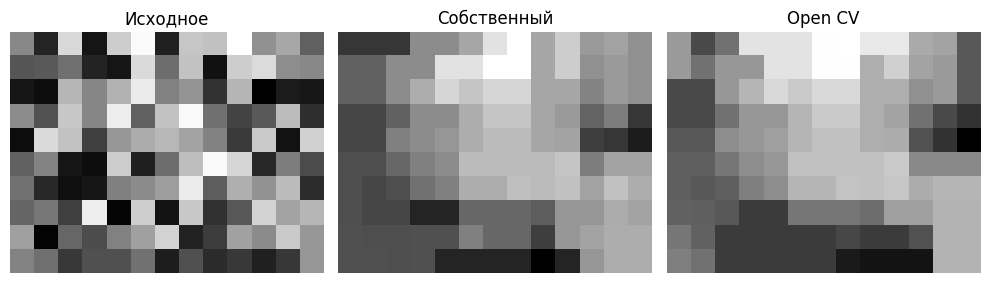

In [68]:
H = 1
W = 3
image_list = [test_arr, arr_med, filtered_image]
label_list = ["Исходное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(10,10))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i], cmap='gray')  
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i], cmap='gray')
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

In [69]:
image_list = [test_arr, arr_med, filtered_image]
for i in range(len(image_list)):
    print(image_list[i].squeeze())
    print()

[[135  37 216  21 204 250  32 197 192 254 144 166  96]
 [ 85  89 111  35  21 217 109 193  17 204 218 140 135]
 [ 21  13 181 133 177 234 128 146  50 180   0  27  23]
 [139  82 198 133 236  97 193 248 112  67  89 187  46]
 [ 12 217 193  63 150 171 182 162 129  58 200  18 208]
 [ 97 130  21  13 203  31 109 188 248 213  40 125  75]
 [114  40  15  22 127 138 157 235  93 174 145 186  45]
 [101 119  63 236   5 205  19 199  48  87 211 163 181]
 [159   3 102  76 128 159 209  34  61 160 138 201 150]
 [130 112  57  80  80 114  29  80  43  57  33  55 149]]

[[ 89  89  89 133 133 146 177 192 146 166 140 144 135]
 [111 111 133 133 177 177 192 192 146 166 135 140 135]
 [111 111 133 150 171 162 171 171 146 146 129 140 135]
 [ 97  97 111 133 133 150 162 162 146 140 112 125  89]
 [ 97  97 127 133 138 150 157 157 146 145  93  89  75]
 [101 101 114 127 133 157 157 157 157 162 125 145 145]
 [101  97 101 119 127 150 150 159 157 160 145 160 150]
 [101  97  97  80  80 114 114 114 109 138 138 149 145]
 [102 10

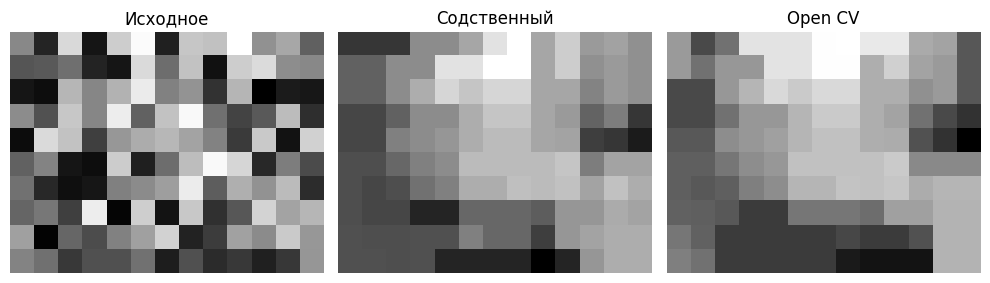

In [70]:
H = 1
W = 3
image_list = [test_arr, arr_med, filtered_image]
label_list = ["Исходное", "Содственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(10,10))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i], cmap='gray')  
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i], cmap='gray')
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

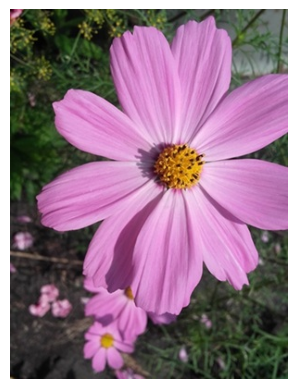

In [72]:
image1 = mpimg.imread('../Sourse_Images/flowers_sm_sz3.jpg')#salt_paper0.jpg
plt.imshow(image1)
plt.axis('off')  # скрыть оси
plt.show()

In [73]:
image1.shape

(400, 300, 3)

In [74]:
image1[1,1,:]

array([46,  2, 15], dtype=uint8)

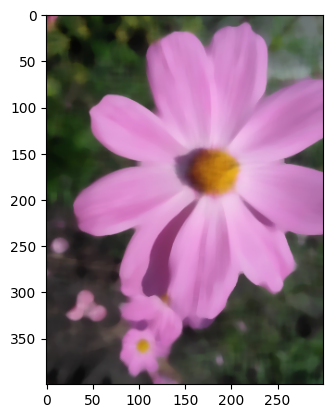

In [75]:
image_filt = cv2.medianBlur(image1, ksize=11)
plt.imshow(image_filt)

In [76]:
#Исходное
image1 = mpimg.imread('../Sourse_Images/salt_paper.png')
#Собственный фильтр
image2 = Median_filter(image1, 5, expand = 2)
#Фильтр CV2
cv2_image = image1.copy()
image_filt = cv2.medianBlur(cv2_image, ksize=5)

100%|██████████| 3/3 [02:16<00:00, 45.41s/it]


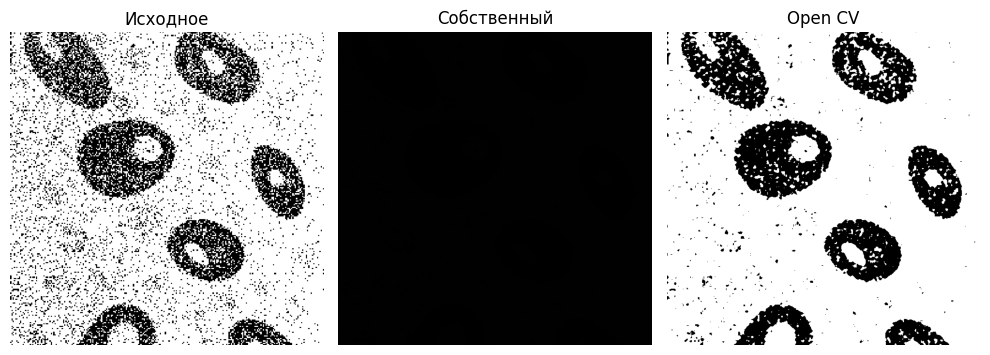

In [77]:
H = 1
W = 3
image_list = [image1, image2, image_filt]
label_list = ["Исходное", "Собственный", "Open CV"]
fig, ax = plt.subplots(H, W, figsize=(10,10))
if H == 1:
    for i in range(W):
        ax[i].imshow(image_list[i])  #, cmap='gray'
        ax[i].axis('off')
        ax[i].set_title(label_list[i])  
else:
    for i in range(H*W):
        h = i // W  
        w = i % W
        ax[h, w].imshow(image_list[i])
        ax[h, w].axis('off')
        ax[h, w].set_title(label_list[i])  

plt.tight_layout()
plt.show()

Для 1 лаб работы по CV необходимо реализовать базовый минимум операций над изображениями
Входное изображение в формате (RGB, не чёрно-белое)
1. Фильтры

1.1 Медианный фильтр

1.2 Фильтр гаусса

2. Морфологические операции

2.1 Эрозия

2.2 Дилатация

3. Прочие операции

3.1 пороговая бинаризация (для rgb и grayscale изображения)

3.2 выравнивание гистограммы

3.3 поворот изображений на угол кратный 90 градусов


3.3 Поворот изображения на угол кратный 90&deg;

In [ ]:
def Rotate(image: np.ndarray, angle: int) -> np.ndarray:
    H = image.shape[0]
    W = image.shape[1]
    C = image.shape[2]
    angle = angle % 360
    if(angle == 0):
        res_image = image.copy()
    elif(angle == 90):
        res_image = np.zeros((W, H, C)) # dtype=image.dtype)
        for k in range(C):
            for i in range(W):
                for j in range(H):
                    res_image[i][j][k] = image[j][i][k]
    elif(angle == 180):
        res_image = np.zeros((H, W, C)) # dtype=image.dtype)
        for k in range(C):
            for i in range(H):
                for j in range(W):
                    res_image[i][j][k] = image[H-1-i][W-1-j][k]
    elif(angle == 270):
        
        res_image = np.zeros((W, H, C)) # dtype=image.dtype)
        for k in range(C):
            for i in range(W):
                for j in range(H):                               
                    res_image[i][j][k] = image[H-1-j][i][k]
    else:
        ####Error
        res_image = np.zeros((H, W, C))
    
    return res_image.astype(np.uint8)


In [ ]:
image2 = Rotate(image1, 180)

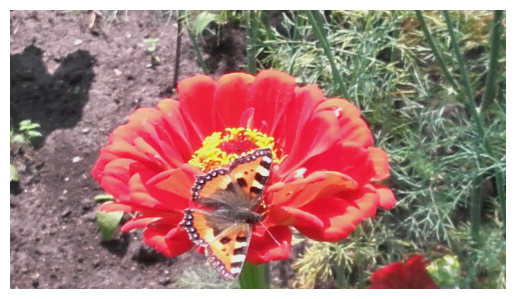

In [ ]:
plt.imshow(image1) #plt.imshow(image1)
#plt.imshow(image2) #plt.imshow(image1)
plt.axis('off')  # скрыть оси
plt.show()

In [ ]:
rotated_image = []
for i in [0, 90, 180, 270]:
    rotated_image.append(Rotate(image1, i))

NameError: name 'rotated_image' is not defined

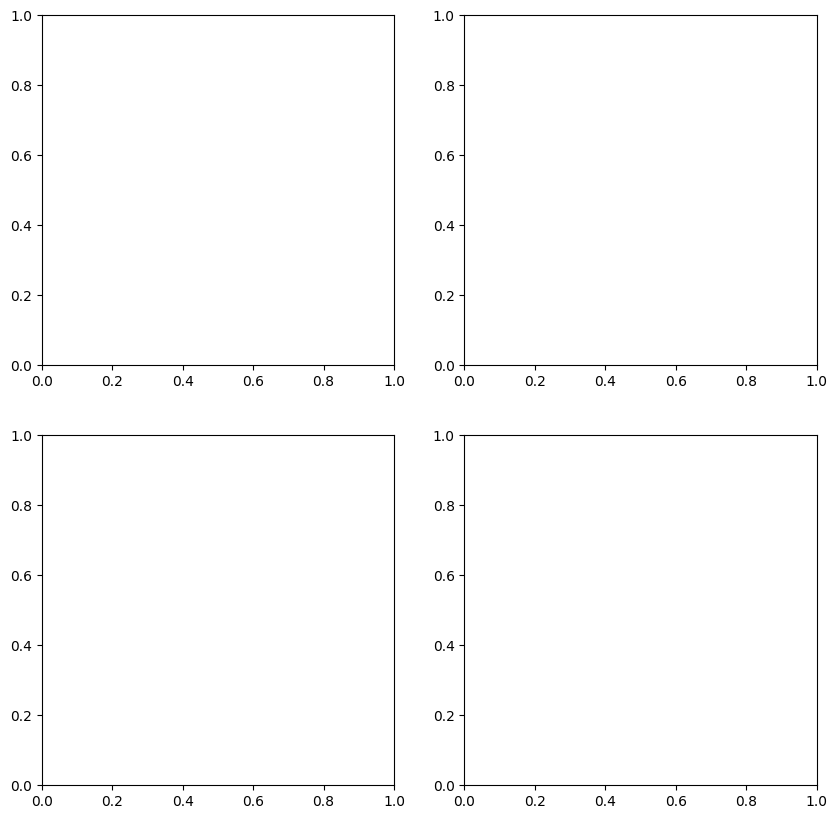

In [ ]:
H = 2
W = 2
fig, ax = plt.subplots(H, W, figsize=(10,10))
for i in range(H*W):
    h = i // W
    w = i % W
    ax[h, w].imshow(rotated_image[i])
    ax[h, w].axis('off')
plt.show()

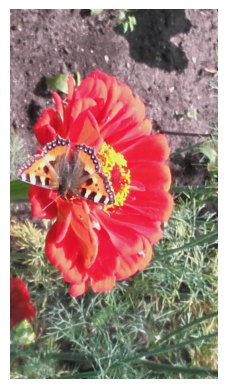

In [ ]:
plt.imshow(img2)
plt.axis('off')  # скрыть оси
plt.show()

In [ ]:
#cv2.imwrite('output.jpg', image)